# SOK-1305 · Prediksjon og klassifikasjon i praksis

**Handelshøgskolen ved UiT · Høsten 2026**

Denne notebooken gjør to ting:

1. **Del 1 – Lineær regresjon og MSE.** Vi bruker `Auto`-datasettet til å predikere
   `mpg`, og måler hvor godt vi treffer med **MSE**. Poenget er skillet mellom
   *trenings*-MSE og *test*-MSE, og hva som skjer når vi skrur opp fleksibiliteten.
2. **Del 2 – Logistisk regresjon og forvekslingsmatrise.** Vi bruker `Default`-datasettet
   til å predikere mislighold, og evaluerer med en **forvekslingsmatrise**
   (*confusion matrix*).

Notebooken henger sammen med Oppgavesett 2: del 1 er oppgave C1, C2 og C4 kjørt på ekte
data, del 2 er oppgave D1 og E4.

> **Før du starter:** installer pakken én gang med `pip install ISLP` i terminalen.

## Oppsett

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS, summarize, poly
from sklearn.model_selection import train_test_split

# Farger vi bruker gjennomgående
TEAL, GULL = '#007396', '#F2A900'
pd.set_option('display.precision', 4)

---
# Del 1 · Lineær regresjon og MSE

## 1.1 Datasettet

`Auto` inneholder 392 bilmodeller. Vi skal predikere `mpg` (miles per gallon) ut fra de
andre variablene. Vi starter med én prediktor: `horsepower`.

In [2]:
Auto = load_data('Auto')
print(Auto.shape)
Auto.head()

(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


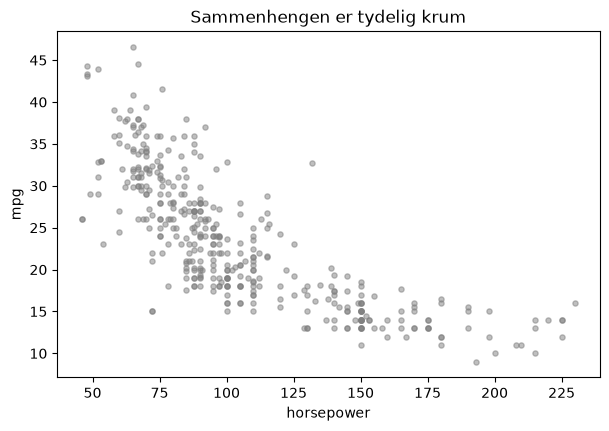

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(Auto['horsepower'], Auto['mpg'], s=14, alpha=0.5, color='grey')
ax.set_xlabel('horsepower'); ax.set_ylabel('mpg')
ax.set_title('Sammenhengen er tydelig krum')
plt.show()

Sammenhengen er negativ, men **ikke lineær**: den flater ut for høye hestekrefter.
Det betyr at en rett linje vil ha systematisk skjevhet, uansett hvor mye data vi har.
Vi kommer tilbake til det i 1.4.

## 1.2 Enkel lineær regresjon

Vi bruker `ModelSpec` til å bygge designmatrisa og `sm.OLS` til å estimere, akkurat som i
laben til kapittel 3.

In [4]:
design = MS(['horsepower']).fit(Auto)
X = design.transform(Auto)
y = Auto['mpg']

modell = sm.OLS(y, X).fit()
summarize(modell)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


## 1.3 MSE, RSS og RSE — tre mål på samme sak

De tre henger sammen slik:

$$
\text{RSS} = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2,
\qquad
\text{MSE} = \frac{\text{RSS}}{n},
\qquad
\text{RSE} = \sqrt{\frac{\text{RSS}}{n-p-1}}.
$$

MSE er gjennomsnittlig kvadrert feil. RSE er nesten det samme, men deler på
frihetsgradene i stedet for på $n$, og tar kvadratrota, slik at den er i samme enhet som
$y$. **MSE er målet vi bruker til å sammenligne modeller**, fordi den også lar seg regne
ut på data modellen ikke har sett.

In [5]:
rss = np.sum(modell.resid**2)
n = len(y)

print(f"RSS  = {rss:8.2f}")
print(f"MSE  = {rss/n:8.2f}   (= RSS/n)")
print(f"RSE  = {np.sqrt(modell.mse_resid):8.2f}   (= sqrt(RSS/(n-2)))")
print(f"R^2  = {modell.rsquared:8.4f}")

RSS  =  9385.92
MSE  =    23.94   (= RSS/n)
RSE  =     4.91   (= sqrt(RSS/(n-2)))
R^2  =   0.6059


En MSE på 23,94 betyr at vi i snitt bommer med 23,94 *kvadrerte* mpg. Kvadratrota,
$\sqrt{23{,}94}\approx 4{,}9$ mpg, er lettere å forholde seg til: typisk bom er rundt
5 mpg, når gjennomsnittlig `mpg` er 23,4.

**Men:** dette er MSE regnet på de samme dataene som modellen ble tilpasset på. Det er
*trenings*-MSE, og den er systematisk for optimistisk.

## 1.4 Del dataene i trening og test

Vi deler tilfeldig i to like store deler. Modellen ser bare treningssettet. Testsettet
holdes utenfor til slutt.

In [6]:
Auto_tren, Auto_test = train_test_split(Auto, test_size=0.5, random_state=1)
print(f"Treningssett: {len(Auto_tren)} biler")
print(f"Testsett:     {len(Auto_test)} biler")

Treningssett: 196 biler
Testsett:     196 biler


In [7]:
def mse_lineaer(tren, test, prediktorer, grad=1):
    # Tilpasser modellen paa treningssettet og returnerer (trenings-MSE, test-MSE)
    if grad > 1:
        spesifikasjon = MS([poly(prediktorer[0], degree=grad)])
    else:
        spesifikasjon = MS(prediktorer)
    d = spesifikasjon.fit(tren)
    mod = sm.OLS(tren['mpg'], d.transform(tren)).fit()
    tren_mse = np.mean((tren['mpg'] - mod.predict(d.transform(tren)))**2)
    test_mse = np.mean((test['mpg'] - mod.predict(d.transform(test)))**2)
    return tren_mse, test_mse


tren_mse, test_mse = mse_lineaer(Auto_tren, Auto_test, ['horsepower'])
print(f"Trenings-MSE: {tren_mse:.2f}")
print(f"Test-MSE:     {test_mse:.2f}")

Trenings-MSE: 23.17
Test-MSE:     24.80


## 1.5 Skru opp fleksibiliteten

Nå gjør vi det samme med polynomer av grad 1 til 10:

$$
\texttt{mpg} = \beta_0 + \beta_1\,\texttt{hp} + \beta_2\,\texttt{hp}^2
+ \dots + \beta_d\,\texttt{hp}^d + \epsilon .
$$

Høyere grad betyr mer fleksibel modell. Se på hva som skjer med de to MSE-ene.

*Teknisk detalj:* `poly()` bygger en ortogonal polynombasis, og den basisen tilpasses
med `.fit(tren)` — altså kun på treningsdataene. Testsettet blir bare transformert.
Det er samme prinsipp som i oppgave C5: alt som ser på dataene, skal skje på
treningssettet.

In [8]:
grader = range(1, 11)
resultat = pd.DataFrame(
    [mse_lineaer(Auto_tren, Auto_test, ['horsepower'], grad=g) for g in grader],
    index=pd.Index(grader, name='grad'),
    columns=['trenings-MSE', 'test-MSE']
)
resultat.round(2)

,trenings-MSE,test-MSE
grad,,
1,23.17,24.80
2,19.45,18.85
3,19.44,18.81
4,19.41,18.71
5,18.96,18.32
6,18.73,18.26
7,18.22,18.71
8,18.20,18.84
9,18.18,18.79


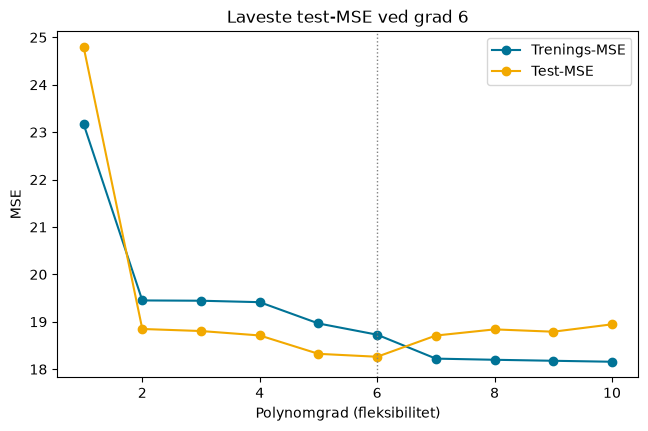

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(resultat.index, resultat['trenings-MSE'], 'o-', color=TEAL,  label='Trenings-MSE')
ax.plot(resultat.index, resultat['test-MSE'],    'o-', color=GULL,   label='Test-MSE')
beste = resultat['test-MSE'].idxmin()
ax.axvline(beste, color='grey', ls=':', lw=1)
ax.set_xlabel('Polynomgrad (fleksibilitet)'); ax.set_ylabel('MSE')
ax.set_title(f'Laveste test-MSE ved grad {beste}')
ax.legend(); plt.show()

**Les figuren:**

- Trenings-MSE synker **monotont**. Den vil alltid gjøre det, fordi en modell av grad
  $d+1$ inneholder modellen av grad $d$ som spesialtilfelle. Dette er nøyaktig poenget i
  oppgave C1 og B4(c).
- Test-MSE stuper fra grad 1 til grad 2 (den krumme sammenhengen fanges opp),
  ligger så flatt, og begynner deretter å stige igjen.

Med 196 treningsobservasjoner er straffen for overfleksibilitet fortsatt mild. La oss
gjøre treningssettet mindre.

## 1.6 Samme øvelse med mindre treningssett

Nå bruker vi bare 98 biler til trening.

In [10]:
tren_liten, test_stor = train_test_split(Auto, test_size=0.75, random_state=0)
print(f"Treningssett: {len(tren_liten)} biler")

resultat_liten = pd.DataFrame(
    [mse_lineaer(tren_liten, test_stor, ['horsepower'], grad=g) for g in grader],
    index=pd.Index(grader, name='grad'),
    columns=['trenings-MSE', 'test-MSE']
)
resultat_liten.round(2)

Treningssett: 98 biler


,trenings-MSE,test-MSE
grad,,
1,22.10,24.79
2,14.59,20.79
3,14.14,21.08
4,14.02,21.48
5,13.82,21.11
6,13.78,20.95
7,13.41,20.91
8,13.25,21.12
9,12.14,23.51


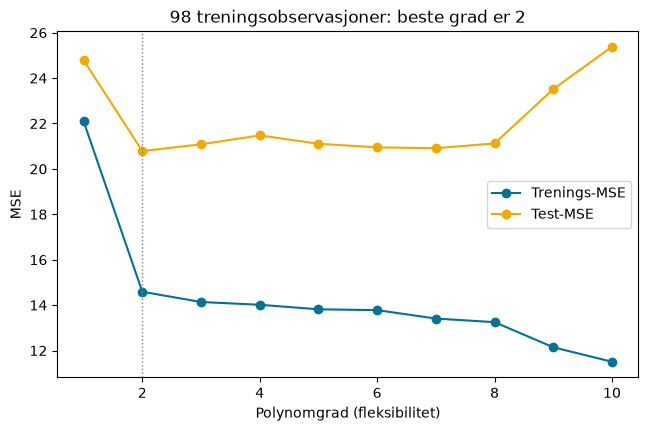

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(resultat_liten.index, resultat_liten['trenings-MSE'], 'o-', color=TEAL, label='Trenings-MSE')
ax.plot(resultat_liten.index, resultat_liten['test-MSE'],     'o-', color=GULL, label='Test-MSE')
ax.axvline(resultat_liten['test-MSE'].idxmin(), color='grey', ls=':', lw=1)
ax.set_xlabel('Polynomgrad (fleksibilitet)'); ax.set_ylabel('MSE')
ax.set_title(f"98 treningsobservasjoner: beste grad er {resultat_liten['test-MSE'].idxmin()}")
ax.legend(); plt.show()

Nå er U-formen tydelig. Trenings-MSE går fra 22 ned til 11,5, mens test-MSE bunner ut på
grad 2 og deretter stiger til over 25.

**Dette er hele bias–varians-avveiningen på ett bilde**, og legg merke til at *hvor*
minimum ligger avhenger av $n$: med lite data lønner det seg med en mindre fleksibel
modell. Det er svaret på oppgave B1(a) og B1(b) i oppgavesett 1.

## 1.7 Hvor mye betyr det hvilken splitt vi tok?

Testfeilen er selv et estimat, basert på ett tilfeldig trekk. Vi gjentar med fem ulike
splitter.

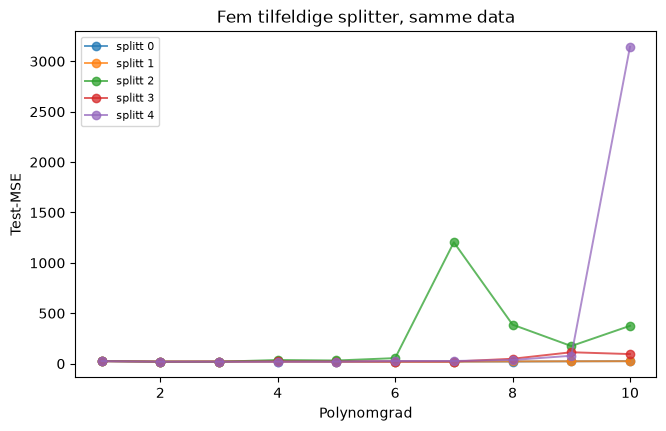

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for seed in range(5):
    tr, te = train_test_split(Auto, test_size=0.75, random_state=seed)
    kurve = [mse_lineaer(tr, te, ['horsepower'], grad=g)[1] for g in grader]
    ax.plot(grader, kurve, 'o-', alpha=0.75, lw=1.4, label=f'splitt {seed}')
ax.set_xlabel('Polynomgrad'); ax.set_ylabel('Test-MSE')
ax.set_title('Fem tilfeldige splitter, samme data')
ax.legend(fontsize=8); plt.show()

Kurvene ligner på hverandre i form, men hverken nivået eller minimumspunktet er likt.
Å velge modell ut fra én enkelt splitt er derfor risikabelt — og det er nettopp problemet
**kryssvalidering** i kapittel 5 løser.

## 1.8 Er modellen bedre enn ingenting?

En MSE-verdi alene sier lite. To referansepunkter er nyttige:

- **Nullmodellen:** predikér alltid gjennomsnittet $\bar{y}$ fra treningssettet.
- **Flere prediktorer:** hjelper det å legge til vekt og årsmodell?

In [13]:
null_mse = np.mean((Auto_test['mpg'] - Auto_tren['mpg'].mean())**2)
print(f"Nullmodell (alltid ybar):  test-MSE = {null_mse:.2f}\n")

modeller = [
    ['horsepower'],
    ['horsepower', 'weight'],
    ['horsepower', 'weight', 'year'],
    ['horsepower', 'weight', 'year', 'displacement', 'acceleration', 'cylinders', 'origin'],
]
rader = []
for prediktorer in modeller:
    tr_mse, te_mse = mse_lineaer(Auto_tren, Auto_test, prediktorer)
    rader.append({'antall prediktorer': len(prediktorer),
                  'trenings-MSE': tr_mse, 'test-MSE': te_mse,
                  'modell': ' + '.join(prediktorer)})
pd.DataFrame(rader).set_index('modell').round(2)

Nullmodell (alltid ybar):  test-MSE = 64.91



,antall prediktorer,trenings-MSE,test-MSE
modell,,,
horsepower,1,23.17,24.80
horsepower + weight,2,15.96,20.11
horsepower + weight + year,3,10.77,12.79
horsepower + weight + year + displacement + acceleration + cylinders + origin,7,9.75,12.63


Nullmodellen har test-MSE på nesten 65. Selv den enkleste regresjonen mer enn halverer
den. Å legge til `weight` og `year` hjelper mye, mens de fire siste variablene knapt
gjør noe — samme mønster som i oppgave B4, der justert $R^2$ og $F$-testen sa at den
tredje variabelen ikke bidro.

---
# Del 2 · Logistisk regresjon og forvekslingsmatrise

## 2.1 Datasettet

`Default` inneholder 10 000 kredittkortkunder. Responsen `default` er kvalitativ:
misligholdt kunden gjelda eller ikke?

In [14]:
Default = load_data('Default')
print(Default.shape)
Default.head()

(10000, 4)


,default,student,balance,income
0,No,No,729.5265,44361.6251
1,No,Yes,817.1804,12106.1347
2,No,No,1073.5492,31767.1389
3,No,No,529.2506,35704.4939
4,No,No,785.6559,38463.4959


In [15]:
antall = Default['default'].value_counts()
andel = Default['default'].value_counts(normalize=True)
pd.DataFrame({'antall': antall, 'andel': andel.round(4)})

,antall,andel
default,,
No,9667,0.9667
Yes,333,0.0333


Bare **3,33 %** misligholder. Klassene er altså sterkt skjevfordelte, og det får
konsekvenser for hvordan vi skal lese resultatene senere.

## 2.2 Tilpass den logistiske modellen

Logistisk regresjon estimeres med `sm.GLM` og `family=sm.families.Binomial()`.
Responsen må være 0/1. Modellen er

$$
\log\!\left(\frac{p(X)}{1-p(X)}\right) = \beta_0 + \beta_1\,\texttt{balance}.
$$

In [16]:
y_mislighold = (Default['default'] == 'Yes').astype(int)

design_d = MS(['balance']).fit(Default)
X_d = design_d.transform(Default)

logit = sm.GLM(y_mislighold, X_d, family=sm.families.Binomial()).fit()
summarize(logit)

,coef,std err,z,P>|z|
intercept,-10.6513,0.361,-29.491,0.0
balance,0.0055,0.000,24.952,0.0


Sammenlign med **tabell 4.1** i boka: $\hat\beta_0 = -10{,}6513$ og
$\hat\beta_1 = 0{,}0055$. Det stemmer.

Merk at kolonnen heter `z` og ikke `t`. Ellers leses utskriften helt likt som i
kapittel 3.

## 2.3 Fra koeffisient til sannsynlighet

$\hat\beta_1 = 0{,}0055$ er endringen i **log-odds** per dollar, ikke i sannsynlighet.
For å få en sannsynlighet må vi gjennom den logistiske funksjonen.

In [17]:
nye = pd.DataFrame({'balance': [1000, 1500, 1900, 2000, 2100]})
p_ny = logit.predict(design_d.transform(nye))

pd.DataFrame({'balance': nye['balance'],
              'p_hatt': p_ny.round(4),
              'odds':   (p_ny/(1-p_ny)).round(4)})

,balance,p_hatt,odds
0,1000,0.0058,0.0058
1,1500,0.0829,0.0905
2,1900,0.4493,0.8160
3,2000,0.5858,1.4141
4,2100,0.7102,2.4508


Kunden med saldo 1000 har under 1 % sannsynlighet, kunden med 2000 har nesten 59 %.
Legg merke til hva 100 dollar ekstra gjør:

- fra 1900 til 2000: $0{,}45 \rightarrow 0{,}59$, altså **+14 prosentpoeng**
- fra 1000 til 1100: knapt en halv prosentpoeng (regn det ut selv)

Samme endring i $X$, helt ulik endring i $p$. Det er oppgave E4, og den vanligste
tolkningsfeilen i kapittel 4.

## 2.4 Fra sannsynlighet til klasse

En sannsynlighet er ikke en prediksjon av klasse. Vi må velge en **terskel**. Den
naturlige startverdien er 0,5: klassifiser som «Ja» hvis $\hat p > 0{,}5$.

In [18]:
p_hatt = logit.predict(X_d)

predikert = np.where(p_hatt > 0.5, 'Ja', 'Nei')
faktisk   = np.where(y_mislighold == 1, 'Ja', 'Nei')

tabell = confusion_table(predikert, faktisk)
tabell

Truth,Ja,Nei
Predicted,,
Ja,100,42
Nei,233,9625


Slik leses den: **radene er det modellen sier, kolonnene er sannheten.**

|                    | Faktisk Ja | Faktisk Nei |
|--------------------|-----------|-------------|
| **Predikert Ja**   | treff     | falsk alarm |
| **Predikert Nei**  | bom       | treff       |

Diagonalen er riktige klassifiseringer, alt utenfor diagonalen er feil.

*(`pd.crosstab(predikert, faktisk)` gir det samme, om du vil se hva som skjer under
panseret.)*

In [19]:
riktig_ja  = tabell.loc['Ja', 'Ja']
falsk_alarm = tabell.loc['Ja', 'Nei']
bommet     = tabell.loc['Nei', 'Ja']
antall_ja  = faktisk.tolist().count('Ja')

print(f"Total feilrate:            {np.mean(predikert != faktisk):.4f}")
print(f"Feilrate, 'alltid Nei':    {antall_ja/len(faktisk):.4f}")
print()
print(f"Misligholdere fanget opp:  {riktig_ja}/{antall_ja} = {riktig_ja/antall_ja:.1%}")
print(f"Falske alarmer:            {falsk_alarm}")
print(f"Mislighold vi overser:     {bommet}")

Total feilrate:            0.0275
Feilrate, 'alltid Nei':    0.0333

Misligholdere fanget opp:  100/333 = 30.0%
Falske alarmer:            42
Mislighold vi overser:     233


Her er poenget fra oppgave D1:

- Feilraten er **2,75 %**, som høres bra ut.
- Men en klassifikator som bare sier «Nei» til alle får **3,33 %**. Vi slår altså den
  late strategien med et halvt prosentpoeng.
- Og vi fanger bare **30 %** av dem som faktisk misligholder. Sett fra banken er det
  ganske dårlig — det er nettopp disse kundene modellen er kjøpt for å finne.

Grunnen er terskelen på 0,5. Med bare 3,3 % misligholdere er det få kunder som i det hele
tatt kommer over 0,5.

## 2.5 Flytt terskelen

Senker vi terskelen, fanger vi flere mislighold, men får flere falske alarmer.

In [20]:
rader = []
for terskel in [0.5, 0.3, 0.2, 0.1, 0.05]:
    pred_t = np.where(p_hatt > terskel, 'Ja', 'Nei')
    t = confusion_table(pred_t, faktisk)
    rader.append({
        'terskel': terskel,
        'total feilrate': np.mean(pred_t != faktisk),
        'andel mislighold fanget': t.loc['Ja', 'Ja'] / antall_ja,
        'falske alarmer': t.loc['Ja', 'Nei'],
    })
oversikt = pd.DataFrame(rader).set_index('terskel')
oversikt.round(4)

,total feilrate,andel mislighold fanget,falske alarmer
terskel,,,
0.50,0.0275,0.3003,42
0.30,0.0313,0.5015,147
0.20,0.0397,0.5976,263
0.10,0.0639,0.7327,550
0.05,0.1031,0.8438,979


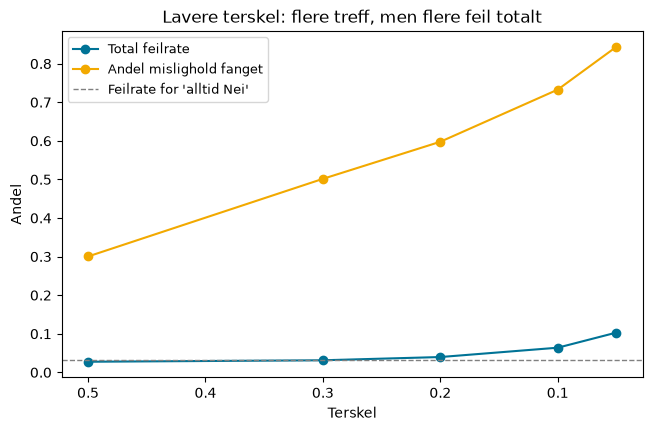

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(oversikt.index, oversikt['total feilrate'], 'o-', color=TEAL,
        label='Total feilrate')
ax.plot(oversikt.index, oversikt['andel mislighold fanget'], 'o-', color=GULL,
        label='Andel mislighold fanget')
ax.axhline(antall_ja/len(faktisk), color='grey', ls='--', lw=1,
           label="Feilrate for 'alltid Nei'")
ax.invert_xaxis()
ax.set_xlabel('Terskel'); ax.set_ylabel('Andel')
ax.set_title('Lavere terskel: flere treff, men flere feil totalt')
ax.legend(fontsize=9); plt.show()

Ved terskel 0,1 fanger vi 73 % av misligholdene, men den totale feilraten stiger til
6,4 %. **Hvilken terskel som er riktig, er ikke et statistisk spørsmål, men et
økonomisk.** Det avhenger av hva et tapt utlån koster i forhold til en avvist kunde som
ville betalt. Statistikken gir deg avveiningen; kostnadene må du hente fra bedriften.

## 2.6 Forvekslingsmatrise på testdata

Alt over er regnet på treningsdataene, og har samme svakhet som trenings-MSE i del 1.
Vi gjør det ordentlig: del først, tilpass på treningssettet, evaluer på testsettet.

Vi bruker samtidig flere prediktorer, som i tabell 4.3 i boka.

In [22]:
Default = Default.assign(
    student01 = (Default['student'] == 'Yes').astype(int),
    inntekt   = Default['income'] / 1000,        # i tusen dollar, som i boka
)

tren_d, test_d = train_test_split(
    Default, test_size=0.3, random_state=0, stratify=Default['default']
)
print(f"Trening: {len(tren_d)},  test: {len(test_d)}")

design_m = MS(['balance', 'inntekt', 'student01']).fit(tren_d)
logit_m = sm.GLM((tren_d['default'] == 'Yes').astype(int),
                 design_m.transform(tren_d),
                 family=sm.families.Binomial()).fit()
summarize(logit_m)

Trening: 7000,  test: 3000


,coef,std err,z,P>|z|
intercept,-10.8524,0.584,-18.585,0.000
balance,0.0055,0.000,20.600,0.000
inntekt,0.0124,0.010,1.274,0.203
student01,-0.4254,0.282,-1.507,0.132


Koeffisienten på `student01` er **negativ**, mens den er positiv i en modell med bare
studentstatus. Det er konfunderingen fra oppgave E5: studenter har høyere saldo, og når
vi kontrollerer for saldo, er en student faktisk den tryggeste av to kunder med lik
saldo.

Merk at koeffisienten ikke er signifikant her ($p = 0{,}13$). Vi bruker bare 70 % av
observasjonene, og med 333 misligholdere totalt blir det tynt. Kjører du modellen på hele
datasettet, får du $-0{,}6468$ med $p = 0{,}0062$, som er tabell 4.3 i boka.

In [23]:
p_test = logit_m.predict(design_m.transform(test_d))
pred_test = np.where(p_test > 0.5, 'Ja', 'Nei')
fakt_test = np.where(test_d['default'] == 'Yes', 'Ja', 'Nei')

tabell_test = confusion_table(pred_test, fakt_test)
print(tabell_test, '\n')

antall_ja_test = (fakt_test == 'Ja').sum()
print(f"Test-feilrate:           {np.mean(pred_test != fakt_test):.4f}")
print(f"Feilrate, 'alltid Nei':  {antall_ja_test/len(fakt_test):.4f}")
print(f"Mislighold fanget:       {tabell_test.loc['Ja','Ja']}/{antall_ja_test}"
      f" = {tabell_test.loc['Ja','Ja']/antall_ja_test:.1%}")

Truth      Ja   Nei
Predicted          
Ja         35    14
Nei        65  2886 

Test-feilrate:           0.0263
Feilrate, 'alltid Nei':  0.0333
Mislighold fanget:       35/100 = 35.0%


Konklusjonen holder på data modellen aldri har sett: feilraten er lav, men den er lav
først og fremst fordi mislighold er sjeldent. Modellen fanger fortsatt bare rundt en
tredjedel av misligholderne ved terskel 0,5.

---
## Oppsummering

| Regresjon | Klassifikasjon |
|---|---|
| Respons er kvantitativ | Respons er kvalitativ |
| Minste kvadraters metode (minimér RSS) | Sannsynlighetsmaksimering |
| Evalueres med **MSE** | Evalueres med **feilrate** og forvekslingsmatrise |
| Referansepunkt: nullmodellen $\bar y$ | Referansepunkt: «alltid den vanligste klassen» |
| `sm.OLS` | `sm.GLM(..., family=Binomial())` |

Det som er felles, og som er kursets røde tråd:

1. **Trenings-feil er ikke test-feil.** Trenings-MSE synker alltid med mer fleksibilitet.
   Det gjør ikke test-MSE.
2. **Ett tall er aldri nok.** MSE må sammenlignes med en nullmodell; feilraten må
   sammenlignes med den late klassifikatoren, og brytes ned i en forvekslingsmatrise.
3. **Én splitt er et støyete estimat.** Det er derfor kapittel 5 handler om
   kryssvalidering.

### Prøv selv

- Bytt ut `horsepower` med `weight` i del 1. Endrer den beste polynomgraden seg?
- Kjør 1.5 med `random_state=42` i splitten. Hvor mye flytter minimumspunktet seg?
- Legg til `student01` og et interaksjonsledd `('balance', 'student01')` i `MS(...)` i
  del 2. Blir test-feilraten bedre?
- Sett terskelen i 2.6 til den verdien du mener en bank burde bruke, og begrunn valget.